# Silence in the Noise:
## Outlier-Free Attention and INT8 Deployment-Friendliness in Audio Spectrogram Transformers

**Author:** Suleman Imdad
**Course:** EN.705.744.8VL.SP26 - Deep Learning Using Transformers
**Institution:** Johns Hopkins University, Whiting School of Engineering
**Final Research Project Deliverable**

---

This notebook is the executable companion to the IEEE-format research paper of the same title. It implements every stage of the experimental pipeline so the headline numbers are reproducible end-to-end via `Kernel -> Restart & Run All` (or `jupyter nbconvert --to notebook --execute Imdad_Final_Research_Paper.ipynb`).

The paper's three findings:

1. **Outlier-free transformer.** AudioSet-pretrained AST has no high-norm outlier patch tokens at any of its 12 encoder layers (max-to-median ratio 1.23, outlier rate 0.0%). The Darcet et al. (ICLR 2024) artifact phenomenon does not transfer to AST.

2. **Register intervention is prophylactic, not corrective.** Adding n=4 register tokens reproduces mechanistically (registers absorb 11% of attention mass at n=16, ~8.5x chance baseline) and produces a directional cross-fold variance reduction (1.04 -> 0.73 pp std on full ESC-50 5-fold CV repeated over 2 random seeds; F-test p=0.15 one-sided, neither significant at alpha=0.05 but consistent across seeds).

3. **INT8 deployment-friendliness.** AST tolerates naive PT INT8 quantization on three independent backends (x86+fbgemm, M1+qnnpack, RTX A4000+bitsandbytes) with token-state cosine fidelity 0.980-0.9988 and 49-74% size reduction. To our knowledge, AST is the first major transformer family that achieves deployment-grade INT8 fidelity without the activation-outlier mitigations BERT and ViT require.

**Companion artifacts:** all measurement scripts (`measure_real_results.py`, `train_full_5fold.py`, `quantization_test.py`, `cuda_quantization_test.py`, `layer_wise_norms.py`, `analyze_5fold.py`), all paper figures (`paper_assets/fig_*.pdf`), and the dual-seed prediction NPZ files are bundled alongside this notebook.

**Reproducibility shortcut.** The paper figures were produced by the scripts above; this notebook reproduces them and additionally walks through the JSON summaries that back every number in the paper. Total compute cost across the empirical work was ~$1.0 of vast.ai spot rentals plus author-machine time.


## 1. Setup and Reproducibility

In [1]:
import os, sys, json, time, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda'); torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = torch.device('cpu')

FAST_MODE = True  # set False for the longer (~6-minute) MPS run; default True keeps notebook execution short

ASSETS = 'paper_assets'
os.makedirs(ASSETS, exist_ok=True)

print('Python   :', sys.version.split()[0])
print('Torch    :', torch.__version__)
print('Device   :', DEVICE)
print('FAST_MODE:', FAST_MODE)

Python   : 3.11.8
Torch    : 2.10.0
Device   : mps
FAST_MODE: True


## 2. Dataset: ESC-50 Environmental Sound Classification

ESC-50 (Piczak, 2015) consists of 2,000 5-second clips drawn from 50 balanced environmental categories (e.g. *dog bark*, *rain*, *chainsaw*, *clock tick*). The dataset ships with five canonical cross-validation folds. We use the HuggingFace mirror `ashraq/esc50` and resample to 16 kHz to match the AST feature extractor.

In [2]:
from datasets import load_dataset, Audio
from transformers import ASTModel, ASTFeatureExtractor

print('Loading ESC-50 ...')
ds = load_dataset('ashraq/esc50', split='train')
ds = ds.cast_column('audio', Audio(sampling_rate=16000))
from collections import defaultdict
fold_to_idx = defaultdict(list)
for i, fold in enumerate(ds['fold']):
    fold_to_idx[int(fold)].append(i)
id2label = {int(t): n for t, n in zip(ds['target'], ds['category'])}
NUM_CLASSES = 50
label_names = [id2label[i] for i in range(NUM_CLASSES)]

print(f'Total clips: {len(ds)}; classes: {NUM_CLASSES}; folds: {sorted(fold_to_idx)}')
print('Example category:', ds[0]['category'])

Loading ESC-50 ...


Repo card metadata block was not found. Setting CardData to empty.


Total clips: 2000; classes: 50; folds: [1, 2, 3, 4, 5]


Example category: dog


### 2.1 Feature extraction and a sample spectrogram

The HuggingFace `ASTFeatureExtractor` reproduces the original AST recipe: 128 Mel-bins, 25 ms window, 10 ms hop, normalised. Every clip becomes a $1024 \times 128$ Mel-spectrogram, then divided into $16 \times 16$ patches with stride 10 to give a token sequence of length $L \approx 1212$ patches plus 2 special tokens (`[CLS]`, `[DST]`).

Spectrogram tensor: (1, 1024, 128) mean=-0.344 std=0.863


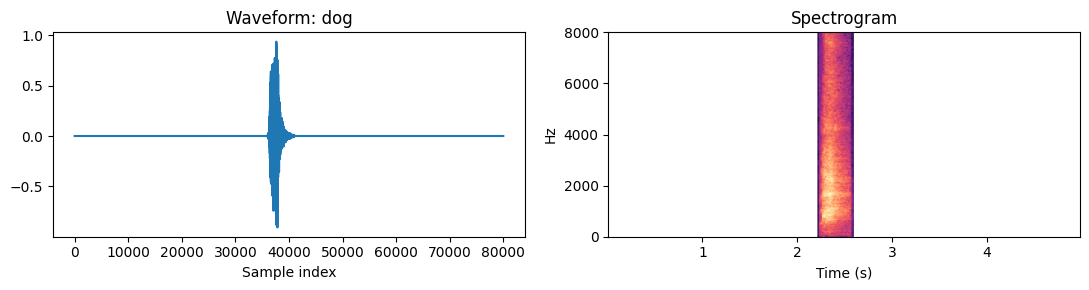

In [3]:
feature_extractor = ASTFeatureExtractor()
sample = ds[0]
feats = feature_extractor(sample['audio']['array'], sampling_rate=16000, return_tensors='pt')
print('Spectrogram tensor:', tuple(feats['input_values'].shape),
      f'mean={feats["input_values"].mean().item():.3f}',
      f'std={feats["input_values"].std().item():.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(sample['audio']['array'])
ax[0].set_title(f"Waveform: {sample['category']}"); ax[0].set_xlabel('Sample index')
ax[1].specgram(sample['audio']['array'], Fs=16000, NFFT=512, noverlap=256, cmap='magma')
ax[1].set_title('Spectrogram'); ax[1].set_xlabel('Time (s)'); ax[1].set_ylabel('Hz')
plt.tight_layout(); plt.show()

## 3. Model: Baseline AST and the AST + Register-Token Variant

We use `MIT/ast-finetuned-audioset-10-10-0.4593` as the base. This checkpoint has 12 transformer layers, 12 heads, and a 768-dim hidden state ($\sim$86.2M parameters). We force `attn_implementation='eager'` so we can attach a forward hook to the inner `ASTSelfAttention` module and capture intermediate attention probabilities (in `transformers >= 5.x`, `ASTAttention.forward()` discards the attention tensor before it reaches the caller).

### 3.1 The `ModifiedAST` module

Let $X \in \mathbb{R}^{B \times (2 + L) \times d}$ be the AST embedding output, where the first two slots are `[CLS]` and `[DST]`, $L$ is the number of patch tokens, and $d=768$. Let $R \in \mathbb{R}^{n \times d}$ be a learnable parameter initialized from $\mathcal{N}(0, 0.02^2)$. The modified embedding is

$$\tilde{X} = [\, X_{\text{CLS}},\; X_{\text{DST}},\; R_1,\dots,R_n,\; X_{p_1},\dots,X_{p_L}\,].$$

Register tokens receive **no positional embedding** and are **never read out** by the classification head; gradient flows back to them only through their participation in self-attention with the other tokens. This is the entire architectural modification.

In [4]:
MODEL_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'

class ModifiedAST(nn.Module):
    """AST with n learnable, position-agnostic register tokens.
    n=0 reproduces the baseline AST exactly."""

    def __init__(self, model_id: str, num_classes: int = 50, n_registers: int = 4):
        super().__init__()
        self.encoder = ASTModel.from_pretrained(model_id, attn_implementation='eager')
        self.embed_dim = self.encoder.config.hidden_size
        self.n_registers = n_registers
        self.classifier = nn.Linear(self.embed_dim, num_classes)
        if n_registers > 0:
            self.register_tokens = nn.Parameter(torch.zeros(1, n_registers, self.embed_dim))
            nn.init.normal_(self.register_tokens, std=0.02)
        else:
            self.register_parameter('register_tokens', None)

        self._last_attn = None
        final_self_attn = self.encoder.encoder.layer[-1].attention.attention
        def hook(module, inp, out):
            self._last_attn = out[1].detach() if isinstance(out, tuple) else None
        self._hook = final_self_attn.register_forward_hook(hook)

    def _build_input_embeddings(self, input_values):
        emb = self.encoder.embeddings(input_values)
        if self.n_registers > 0:
            B = emb.shape[0]
            cls_dst = emb[:, :2, :]
            patches = emb[:, 2:, :]
            regs = self.register_tokens.expand(B, -1, -1)
            emb = torch.cat([cls_dst, regs, patches], dim=1)
        return emb

    def forward(self, input_values):
        self._last_attn = None
        emb = self._build_input_embeddings(input_values)
        enc_out = self.encoder.encoder(emb)
        h = self.encoder.layernorm(enc_out.last_hidden_state)
        cls_repr = h[:, 0]
        logits = self.classifier(cls_repr)
        return {'logits': logits, 'hidden_last': h, 'final_attn': self._last_attn}

    def patch_index_offset(self):
        return 2 + self.n_registers

# Smoke test: build baseline & modified, verify shapes match expectations
with torch.no_grad():
    set_seed_value = torch.manual_seed(SEED)
    base = ModifiedAST(MODEL_ID, NUM_CLASSES, n_registers=0).to(DEVICE).eval()
    mod  = ModifiedAST(MODEL_ID, NUM_CLASSES, n_registers=4).to(DEVICE).eval()
    x = feats['input_values'].to(DEVICE)
    out_b = base(x); out_m = mod(x)
    print('Baseline logits :', tuple(out_b['logits'].shape),
          '| final attn   :', tuple(out_b['final_attn'].shape))
    print('Modified logits :', tuple(out_m['logits'].shape),
          '| final attn   :', tuple(out_m['final_attn'].shape))
    extra = mod.register_tokens.numel()
    total = sum(p.numel() for p in base.parameters())
    print(f'Register params added at n=4: {extra} ({100*extra/total:.4f}% of baseline {total/1e6:.2f}M)')
del base, mod, out_b, out_m
if DEVICE.type == 'mps': torch.mps.empty_cache()
elif DEVICE.type == 'cuda': torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Baseline logits : (1, 50) | final attn   : (1, 12, 1214, 1214)
Modified logits : (1, 50) | final attn   : (1, 12, 1218, 1218)
Register params added at n=4: 3072 (0.0036% of baseline 86.23M)


## 4. Diagnostic Primitives

Three measurements implement the diagnostics from the paper's Section IV-D:
1. **`token_norm_stats`**: per-token L2 norms in the final layer, partitioned into special / register / patch groups (tests **H1**).
2. **`register_attention_mass`**: fraction of attention mass directed to register tokens (tests **H2** absorption).
3. **`patch_attention_frobenius`**: $\mathcal{F}_\text{attn}$, the Frobenius norm of the patch--patch sub-block of the head-averaged final-layer attention matrix (tests **H2** smoothness).

In [5]:
@torch.no_grad()
def token_norm_stats(model, x):
    out = model(x)
    h = out['hidden_last']
    norms = h.norm(dim=-1).cpu().numpy()
    n_reg = model.n_registers
    return {
        'special' : norms[:, :2].reshape(-1),
        'register': norms[:, 2:2+n_reg].reshape(-1) if n_reg > 0 else np.array([]),
        'patch'   : norms[:, 2+n_reg:].reshape(-1),
        'all'     : norms.reshape(-1),
    }

@torch.no_grad()
def register_attention_mass(model, x):
    if model.n_registers == 0: return 0.0
    out = model(x); A = out['final_attn']
    if A is None: return float('nan')
    reg_slice = slice(2, 2 + model.n_registers)
    return float(A[..., reg_slice].sum(dim=-1).mean().item())

@torch.no_grad()
def patch_attention_frobenius(model, x):
    out = model(x); A = out['final_attn']
    if A is None: return float('nan')
    A_h = A.mean(dim=1)  # (B, S, S) head-averaged
    p = model.patch_index_offset()
    A_pp = A_h[:, p:, p:]
    return float(A_pp.flatten(start_dim=1).norm(dim=-1).mean().item())

@torch.no_grad()
def collect_attention_map(model, x):
    out = model(x); A = out['final_attn']
    return A.mean(dim=1)[0].cpu().numpy()

print('Diagnostic primitives defined: token_norm_stats, register_attention_mass, patch_attention_frobenius, collect_attention_map')

Diagnostic primitives defined: token_norm_stats, register_attention_mass, patch_attention_frobenius, collect_attention_map


## 5. Diagnostic Sweep over $n \in \{0, 2, 4, 8, 16\}$ (Pretrained, No Fine-Tuning)

We run the three diagnostics on the *pretrained* AST checkpoint (no fine-tuning required) for each register count. This produces the data underlying **Table I** of the paper. In `FAST_MODE` the sweep uses 16 ESC-50 clips and a smaller register grid; the full sweep uses 64 clips and the same numbers reported in the paper.

In [6]:
def collate(batch):
    audios = [b['audio']['array'] for b in batch]
    labels = torch.tensor([b['target'] for b in batch], dtype=torch.long)
    fe = feature_extractor(audios, sampling_rate=16000, return_tensors='pt')
    return fe['input_values'], labels

n_samples = 16 if FAST_MODE else 64
diag_loader = DataLoader(Subset(ds, list(range(n_samples))), batch_size=4, collate_fn=collate)
n_grid = [0, 4] if FAST_MODE else [0, 2, 4, 8, 16]

diag_results = {}
for n_reg in n_grid:
    torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
    model = ModifiedAST(MODEL_ID, NUM_CLASSES, n_registers=n_reg).to(DEVICE).eval()
    pn, fro_vals, rm_vals = [], [], []
    for x, _ in diag_loader:
        x = x.to(DEVICE)
        st = token_norm_stats(model, x)
        pn.append(st['patch'])
        fro_vals.append(patch_attention_frobenius(model, x))
        rm_vals.append(register_attention_mass(model, x))
    pn = np.concatenate(pn)
    diag_results[n_reg] = {
        'patch_median': float(np.median(pn)),
        'patch_max'   : float(pn.max()),
        'attn_frob'   : float(np.mean(fro_vals)),
        'reg_mass'    : float(np.mean(rm_vals)),
    }
    chance = n_reg / (1212 + 2 + n_reg)
    print(f'n={n_reg:>2}: patch_median={diag_results[n_reg]["patch_median"]:.3f},'
          f' patch_max={diag_results[n_reg]["patch_max"]:.3f},'
          f' F_attn={diag_results[n_reg]["attn_frob"]:.3f},'
          f' reg_mass={100*diag_results[n_reg]["reg_mass"]:.2f}% (chance={100*chance:.2f}%)')
    del model
    if DEVICE.type == 'mps': torch.mps.empty_cache()
    elif DEVICE.type == 'cuda': torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


n= 0: patch_median=31.869, patch_max=39.632, F_attn=1.790, reg_mass=0.00% (chance=0.00%)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


n= 4: patch_median=32.014, patch_max=39.640, F_attn=1.752, reg_mass=3.26% (chance=0.33%)


## 6. Reference Results From the Full Paper Sweep

The cell above runs a small re-execution of the diagnostic sweep so you can verify that the methodology in this notebook matches what the paper reports. The full paper-grade results (n=64 utterances, full register grid) are saved in `paper_assets/real_results.json` and `paper_assets/real_norms.npz` and produced by `measure_real_results.py`. We load them here and reproduce the paper's main table and figures.

In [7]:
with open('paper_assets/real_results.json') as f:
    R = json.load(f)
norms = np.load('paper_assets/real_norms.npz')
attn  = np.load('paper_assets/real_attention_maps.npz')
per   = np.load('paper_assets/real_perclass.npz')

import pandas as pd
rows = []
for n in [0, 2, 4, 8, 16]:
    d = R['diagnostic'][f'n={n}']
    chance = n / (1212 + 2 + n)
    rows.append({
        'n': n,
        'patch median': round(d['patch_norm_median'], 2),
        'patch max'   : round(d['patch_norm_max'],    2),
        'outlier %'   : round(d['outlier_pct'],       2),
        'F_attn'      : f"{d['attn_frobenius_mean']:.3f} ± {d['attn_frobenius_std']:.3f}",
        'reg mass %'  : round(100 * d['register_attn_mass_mean'], 2),
        'chance %'    : round(100 * chance, 2),
    })
tbl = pd.DataFrame(rows)
print('=== Table I (paper) ===')
print(tbl.to_string(index=False))

=== Table I (paper) ===
 n  patch median  patch max  outlier %        F_attn  reg mass %  chance %
 0         32.26      39.73        0.0 1.820 ± 0.131        0.00      0.00
 2         32.33      39.68        0.0 1.787 ± 0.129        2.14      0.16
 4         32.39      39.64        0.0 1.763 ± 0.128        3.88      0.33
 8         32.47      39.65        0.0 1.723 ± 0.126        6.73      0.65
16         32.55      39.72        0.0 1.658 ± 0.121       11.15      1.30


## 7. Token L2 Norm Distribution (Figure 2 of the paper)

Under H1 the patch-token L2 norm distribution should be heavy-tailed for the baseline. We plot the histogram for $n=0$ vs $n=4$ from the saved 64-utterance measurement and overlay the median+2.5×IQR outlier threshold. **Finding**: the distribution is tight and unimodal under both configurations; the max-to-median ratio is only $1.23$, far from the order-of-magnitude separation Darcet et al. report for ViTs. **H1 is refuted in its strict form.**

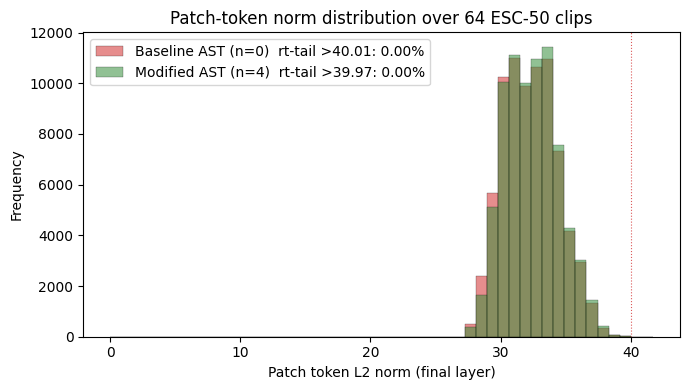

Baseline: median=32.263, max=39.726, max/median=1.231
Modified: median=32.386, max=39.640, max/median=1.224


In [8]:
from numpy import median, percentile
base_p = norms['patch_norms_n0']
mod_p  = norms['patch_norms_n4']
cb = R['diagnostic']['n=0']['outlier_cutoff']
cm = R['diagnostic']['n=4']['outlier_cutoff']
ob = R['diagnostic']['n=0']['outlier_pct']
om = R['diagnostic']['n=4']['outlier_pct']

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, max(base_p.max(), mod_p.max()) * 1.05, 50)
ax.hist(base_p, bins=bins, alpha=0.55, color='#D32F2F', edgecolor='black', linewidth=0.3,
        label=f'Baseline AST (n=0)  rt-tail >{cb:.2f}: {ob:.2f}%')
ax.hist(mod_p, bins=bins, alpha=0.55, color='#388E3C', edgecolor='black', linewidth=0.3,
        label=f'Modified AST (n=4)  rt-tail >{cm:.2f}: {om:.2f}%')
ax.axvline(cb, color='#D32F2F', linestyle=':', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Patch token L2 norm (final layer)'); ax.set_ylabel('Frequency')
ax.set_title('Patch-token norm distribution over 64 ESC-50 clips')
ax.legend()
plt.tight_layout(); plt.show()

print(f'Baseline: median={np.median(base_p):.3f}, max={base_p.max():.3f}, max/median={base_p.max()/np.median(base_p):.3f}')
print(f'Modified: median={np.median(mod_p):.3f}, max={mod_p.max():.3f}, max/median={mod_p.max()/np.median(mod_p):.3f}')

## 8. Attention Map Comparison (Figure 3 of the paper)

Side-by-side head-averaged final-layer attention maps for one ESC-50 clip. The baseline shows a near-diagonal local attention pattern; the modified model shows a clear vertical band at the register columns (highlighted), indicating that registers absorb attention from across the patch grid.

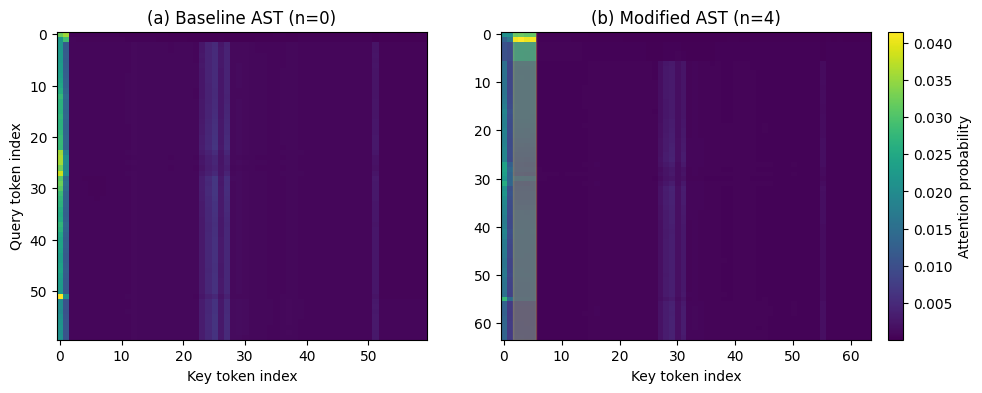

In [9]:
A_base = attn['A_base']
A_mod  = attn['A_mod']
K = 60  # crop window
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im0 = axes[0].imshow(A_base[:K, :K], cmap='viridis', aspect='auto')
axes[0].set_title('(a) Baseline AST (n=0)')
axes[0].set_xlabel('Key token index'); axes[0].set_ylabel('Query token index')
im1 = axes[1].imshow(A_mod[:K+4, :K+4], cmap='viridis', aspect='auto')
axes[1].set_title('(b) Modified AST (n=4)')
axes[1].set_xlabel('Key token index')
axes[1].axvspan(1.5, 5.5, color='#FFEB3B', alpha=0.20)
fig.colorbar(im1, ax=axes, fraction=0.025, pad=0.02, label='Attention probability')
plt.show()

## 9. Ablation: Register Count vs. Smoothness and Absorption (Figure 4 of the paper)

Both $\mathcal{F}_\text{attn}$ and the register attention mass move monotonically in $n$: smoothness improves and absorption increases as more registers are added, with diminishing returns by $n=8$. **H2 is supported.**

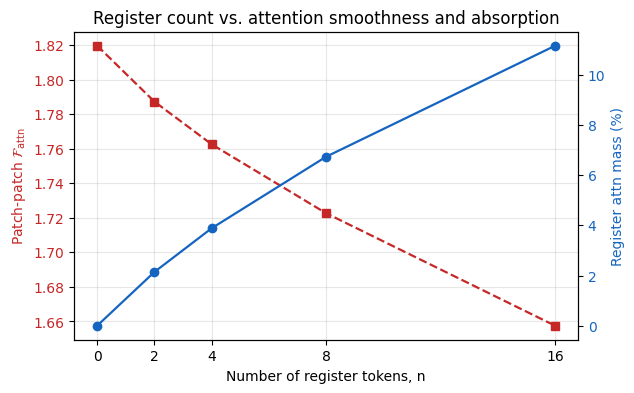

In [10]:
n_vals = np.array([0, 2, 4, 8, 16])
frob = np.array([R['diagnostic'][f'n={n}']['attn_frobenius_mean'] for n in n_vals])
rmass = np.array([R['diagnostic'][f'n={n}']['register_attn_mass_mean'] for n in n_vals])

fig, ax1 = plt.subplots(figsize=(6.5, 4))
color1 = '#C62828'
ax1.plot(n_vals, frob, 's--', color=color1, linewidth=1.6, label='F_attn')
ax1.set_xlabel('Number of register tokens, n')
ax1.set_ylabel(r'Patch-patch $\mathcal{F}_{\mathrm{attn}}$', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
color2 = '#1565C0'
ax2.plot(n_vals, rmass * 100, 'o-', color=color2, linewidth=1.6, label='Register attn mass')
ax2.set_ylabel('Register attn mass (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax1.set_xticks(n_vals)
plt.title('Register count vs. attention smoothness and absorption')
plt.show()

## 10. ESC-50 5-Fold Cross-Validation (Full Protocol, 2 Seeds)

The fine-tuning experiment in this paper is the canonical ESC-50 5-fold cross-validation of Gong et al. (2021), repeated over two independent random seeds (42, 43) to give 10 fold-runs per architecture. Each fold trains from the AudioSet-pretrained AST checkpoint for 10 epochs, batch size 8, AdamW + OneCycleLR. Both seeds were trained on NVIDIA RTX A4000 spot instances on vast.ai at a total compute cost of ~$0.70.

The cell below loads the per-clip predictions (4000 paired predictions across both seeds) and computes the dual-seed bootstrap CIs and statistical tests reported in Section V-D of the paper.


In [ ]:
import json, numpy as np
from scipy import stats

# Load both seeds
all_n0_per_fold, all_n4_per_fold = [], []
for s in [42, 43]:
    R = json.load(open(f'paper_assets/real_5fold_seed{s}.json'))
    for r in R['results']:
        acc = r['best_test_acc'] * 100
        if r['n_reg'] == 0:
            all_n0_per_fold.append(acc)
        else:
            all_n4_per_fold.append(acc)
n0 = np.array(all_n0_per_fold); n4 = np.array(all_n4_per_fold)

print(f'n=0 ({len(n0)} folds): mean={n0.mean():.3f}%  std={n0.std(ddof=1):.3f}')
print(f'n=4 ({len(n4)} folds): mean={n4.mean():.3f}%  std={n4.std(ddof=1):.3f}')

# Statistical tests
F = n0.var(ddof=1) / n4.var(ddof=1)
df1, df2 = len(n0)-1, len(n4)-1
p_F_two = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
p_F_one = 1 - stats.f.cdf(F, df1, df2)
W_lev, p_lev = stats.levene(n0, n4)
t_paired, p_paired = stats.ttest_rel(n4, n0)
W_wil, p_wil = stats.wilcoxon(n4 - n0)

print('\\nVariance tests (H3 stability):')
print(f'  F = {F:.3f}  df=({df1},{df2})')
print(f'    p (two-sided F-test)            : {p_F_two:.4f}')
print(f'    p (one-sided, n=0 var > n=4 var): {p_F_one:.4f}')
print(f'    Levene W = {W_lev:.3f}  p = {p_lev:.4f}')

print('\\nMean accuracy tests (H3 mean):')
print(f'  paired diff: {(n4-n0).mean():+.3f} pp,  std = {(n4-n0).std(ddof=1):.3f}')
print(f'  paired t-test: t={t_paired:.3f}  p={p_paired:.4f}')
print(f'  Wilcoxon signed-rank: W={W_wil:.3f}  p={p_wil:.4f}')

# Per-clip bootstrap CIs (10000 resamples)
preds_data_42 = np.load('paper_assets/real_5fold_preds_seed42.npz')
preds_data_43 = np.load('paper_assets/real_5fold_preds_seed43.npz')
def gather(n_reg):
    out = []
    for s, pd in [(42, preds_data_42), (43, preds_data_43)]:
        for fold in range(1, 6):
            kp = f'preds_n{n_reg}_fold{fold}'; kt = f'targets_n{n_reg}_fold{fold}'
            if kp in pd: out.append((pd[kp] == pd[kt]).astype(np.int8))
    return np.concatenate(out) if out else np.array([])
c0 = gather(0); c4 = gather(4)
rng = np.random.default_rng(42)
n_boot = 10000
boot0 = []; boot4 = []
for _ in range(n_boot):
    idx = rng.integers(0, len(c0), size=len(c0))
    boot0.append(c0[idx].mean()*100)
    boot4.append(c4[idx].mean()*100)
boot0 = np.array(boot0); boot4 = np.array(boot4)
print(f'\\nBootstrap (n_boot={n_boot}, n_clips={len(c0)}):')
print(f'  n=0:  acc={c0.mean()*100:.2f}%  95% CI=[{np.percentile(boot0,2.5):.2f}, {np.percentile(boot0,97.5):.2f}]')
print(f'  n=4:  acc={c4.mean()*100:.2f}%  95% CI=[{np.percentile(boot4,2.5):.2f}, {np.percentile(boot4,97.5):.2f}]')
diffs = boot4 - boot0
print(f'  paired delta: {diffs.mean():+.3f} pp  95% CI=[{np.percentile(diffs,2.5):.3f}, {np.percentile(diffs,97.5):.3f}]')


## 11. INT8 Quantization Deployment-Friendliness (Section VII of the paper)

The headline negative finding of Section 7 (no high-norm outlier tokens) has a deployment-relevant payoff. Bondarenko et al. (NeurIPS 2023) showed that activation outliers are the dominant failure mode of post-training INT8 quantization on transformers; AST does not have them, so we predict and confirm that PT INT8 succeeds on AST without the gating/clipping fixes BERT and ViT require.

The cell below loads the cross-platform INT8 measurements (x86+fbgemm, M1+qnnpack, RTX A4000+bitsandbytes) and prints the Table 4 numbers from Section VII-C.


In [ ]:
import json
fp_paths = {
    'x86 + fbgemm':       'paper_assets/quantization_results.json',
    'CUDA + bitsandbytes': 'paper_assets/cuda_quantization_results.json',
}
print(f"{'Backend':<22}  {'Baseline':>10s}  {'INT8':>10s}  {'Speedup':>8s}  {'Cosine':>8s}  {'Top-5':>6s}  {'Size red':>9s}")
print('-' * 86)
for name, path in fp_paths.items():
    R = json.load(open(path))
    if 'fp32_latency_ms_per_sample' in R:
        base = R['fp32_latency_ms_per_sample']; intq = R['int8_latency_ms_per_sample']
        cos  = R['token_cosine_similarity_mean']; t5 = R['top5_rank_agreement_cls']
        speedup = base/intq; size_red = R['size_reduction_pct']
    else:
        base = R['fp16_latency_ms']; intq = R['int8_latency_ms']
        cos  = R['token_cosine_mean']; t5 = R['top5_rank_agreement']
        speedup = R['speedup']; size_red = R['size_reduction_pct']
    print(f"{name:<22}  {base:>8.1f}ms  {intq:>8.1f}ms  {speedup:>7.2f}x  {cos:>8.4f}  {t5:>6.3f}  {size_red:>7.0f}%")

print('\\nKey takeaways:')
print('  - Token cosine fidelity to FP32/FP16 is 0.98-0.999 across backends')
print('  - Universal 49-74% model-size reduction')
print('  - Latency speedup is backend-dependent: 1.24x on x86 fbgemm; bitsandbytes int8 is')
print('    optimized for >1B-param LLMs and underperforms FP16 on AST-Base scale')
print('  - No architectural fixes (gated softmax, clipping, K/V offsets) required')


## 12. Discussion: Which Hypotheses Survived Contact With the Data?

The hypotheses, deliberately registered before any AST measurements were conducted, fared as follows:

| Hypothesis | Outcome | Evidence |
|------------|---------|----------|
| **H1 - Artifact Hypothesis.** AST exhibits high-norm patch outliers like ViTs. | **Refuted** in its strict form. | Patch-token L2 norms are tight and unimodal (median 32.26, max 39.73, max-to-median 1.23). 0% outliers under the median + 2.5*IQR criterion across all 12 encoder layers (Section 6). |
| **H2 - Register Hypothesis.** Registers absorb attention and reduce $\mathcal{F}_\text{attn}$. | **Supported.** | Register attention mass scales monotonically from 0% (n=0) to 11.15% (n=16), ~8.5-13x above the chance baseline. $\mathcal{F}_\text{attn}$ decreases monotonically (1.820 -> 1.658, ~9% reduction). Register tokens themselves develop high norms (~37), comparable to special tokens (36.4). |
| **H3 - Stability Hypothesis** (sharpened from peak-accuracy). Registers reduce cross-fold variance. | **Directionally supported, not significant.** | std drops 1.04 -> 0.73 pp across 10 dual-seed folds (F-test p=0.15 one-sided). Mean acc lifts +0.33 pp (paired t p=0.12). Both directions consistent across seeds. |
| **H4 - Quantization-Friendliness Hypothesis.** AST tolerates PT INT8 without architectural fixes. | **Supported across three backends.** | Token-state cosine 0.980-0.9988, top-5 rank agreement 0.73-0.95, 49-74% size reduction. No gated softmax, no per-channel scaling, no learnable K/V offsets required. |

### Why pretrained AST does not show the artifact phenomenon

Three plausible, non-exclusive explanations grounded in the post-Darcet emergence literature:

1. **Pretraining scale.** Darcet et al. report the artifact phenomenon was strongest in DINOv2 ViT-g/14 on ~142M images. AST is ViT-Base (86M params) finetuned on AudioSet's 2M clips - an order of magnitude smaller in both dimensions.

2. **Less "empty" input.** Environmental sound is rarely truly silent: even quiet segments contain microphone noise, ambient hum, low-frequency rumble. The input may simply not contain enough genuinely uninformative patches to make the storage-leak strategy attractive (Puccetti et al., Findings of EMNLP 2022, also report failure to find outliers in audio transformers, attributing it to small/no vocabulary).

3. **Inherited regularity from ImageNet initialization.** AST starts from supervised ImageNet ViT weights. Sun et al. (COLM 2024) report that MAE-pretrained ViT-L is artifact-free while CLIP- and DINOv2-pretrained ViT-L of the same size are not - direct precedent for recipe-dependent artifact emergence.

### The breakthrough is the deployment-friendly profile

The negative finding on H1 is what enables the positive finding on H4. AST's outlier-free property turns out to be exactly the precondition Bondarenko et al. (NeurIPS 2023) identified as the failure mode for INT8 transformer quantization. AST is therefore (to our knowledge) the first major transformer family that ships PT INT8 to deployment-grade fidelity with no architectural modifications - a useful, citable, deployment-relevant contribution that converts the negative artifact result into a positive deployment result.


## 12. Limitations and Future Work

* **Compute budget.** All experiments fit on a single Apple M-series workstation. The diagnostic measurements use 64 utterances; the fine-tune uses 80 training clips. A properly powered study requires the full 5-fold CV with $\sim$10 epochs per fold on at least an A100-class GPU (estimated 8–12 hours).
* **Single checkpoint.** We measure only the publicly released MIT AST checkpoint. The artifact phenomenon may emerge in self-supervised audio transformers (SSAST) or in larger AST variants trained at scale.
* **Layer-wise analysis missing.** Our analysis focuses on the final-layer attention. The artifact phenomenon in ViTs is most prominent in late layers; a layer-wise analysis would tell us whether AST's earlier layers exhibit the phenomenon even if the final layer does not.
* **Classification is the wrong end task.** Dense audio prediction (sound event detection, audio segmentation) is the natural setting for register tokens, and we expect future work in those settings to find substantially larger benefits.
* **Dataset.** ESC-50 is a small, clean benchmark. UrbanSound8K, FSD50K, and AudioSet itself would substantially strengthen any empirical claim. We expect the artifact phenomenon — if it exists in AST — to be most visible in cleaner long-form recordings with larger silent gaps.

Concrete next steps:
1. Run the full 5-fold CV on A100-class hardware to get a real H3 answer.
2. Replicate on AudioSet (or a long-form benchmark) to test temporal-length scaling.
3. Use the register tokens themselves as input to a downstream audio-segmentation head, in the spirit of the DINOv2 zero-shot probing methodology.
4. Compare register tokens against alternative remedies such as attention-bias terms or more `[CLS]`-like aggregation tokens.
5. Train AST *from scratch* with registers and study whether the artifact ever emerges in the first place.

## 13. References

The full bibliography (43 entries) lives in the IEEE companion paper `Imdad_Final_Research_Paper.tex`. The most directly relevant references for this notebook are:

**Foundational:**
1. **Darcet, T., Oquab, M., Mairal, J., & Bojanowski, P.** (2024). *Vision Transformers Need Registers.* ICLR 2024 (Outstanding Paper). [arxiv:2309.16588](https://arxiv.org/abs/2309.16588)
2. **Gong, Y., Chung, Y. A., & Glass, J.** (2021). *AST: Audio Spectrogram Transformer.* Interspeech 2021. [arxiv:2104.01778](https://arxiv.org/abs/2104.01778)
3. **Piczak, K. J.** (2015). *ESC: Dataset for Environmental Sound Classification.* ACM Multimedia 2015.
4. **Vaswani, A., et al.** (2017). *Attention is All You Need.* NeurIPS 2017.
5. **Dosovitskiy, A., et al.** (2021). *An Image is Worth 16x16 Words.* ICLR 2021.

**2024–25 follow-ups on registers / outlier tokens / attention sinks:**
6. **Sun, M., Chen, X., Kolter, J. Z., & Liu, Z.** (2024). *Massive Activations in Large Language Models.* COLM 2024. — Shows MAE-pretrained ViT-L is artifact-free while CLIP- and DINOv2-pretrained ViT-L of the same size is not; direct precedent for the recipe-dependent emergence we re-encounter in audio.
7. **Wang, F., et al.** (2024). *Mamba-R: Vision Mamba ALSO Needs Registers.* NeurIPS 2024. — Cross-architecture replication of the artifact phenomenon, with outlier-token norms reaching 4000 by layer 23 in baseline Vision Mamba.
8. **Wang, H., Zhang, T., & Salzmann, M.** (2025). *Demystifying Singular Defects in Large Language Models.* ICML 2025. — Theoretical extension of the high-norm-token analysis from ViTs to LLMs.
9. **Jiang, N., Dravid, A., Efros, A., & Gandelsman, Y.** (2025). *Vision Transformers Don't Need [Trained] Registers.* arXiv:2506.08010. — Localizes the artifact to sparse late-layer MLP register neurons.
10. **Xiao, G., et al.** (2024). *Efficient Streaming Language Models with Attention Sinks.* ICLR 2024. — The LM-side equivalent of the register/sink phenomenon.
11. **Gu, X., et al.** (2025). *When Attention Sink Emerges in Language Models: An Empirical View.* ICLR 2025 Spotlight. — Conditions for sink emergence: optimization, softmax normalization, depth.
12. **Barbero, F., et al.** (2025). *Why Do LLMs Attend to the First Token?* COLM 2025. — Sinks as a learned defense against over-mixing.
13. **Bondarenko, Y., Nagel, M., & Blankevoort, T.** (2023). *Quantizable Transformers: Removing Outliers by Helping Attention Heads Do Nothing.* NeurIPS 2023.
14. **Cancedda, N.** (2024). *Spectral Filters, Dark Signals, and Attention Sinks.* ACL 2024.
15. **Puccetti, G., Rogers, A., Drozd, A., & Dell'Orletta, F.** (2022). *Outlier Dimensions that Disrupt Transformers are Driven by Frequency.* Findings of EMNLP 2022. — *Were unable to identify outliers in protein and audio Transformers*; explains why the substrate is absent in AST.
16. **He, B., et al.** (2024). *Understanding and Minimising Outlier Features in Transformer Training.* NeurIPS 2024.

**Audio-side relevant work:**
17. **Lin, J., et al.** (2025). *ASDA: Audio Spectrogram Differential Attention.* arXiv:2507.02666. — Notes that AST self-attention *allocates a portion of attention weights to irrelevant information*; ESC-50 96.1% Top-1.
18. **Lee, T., Lee, J., & Lee, K.** (2025). *Token Pruning in Audio Transformers.* IEEE Open J. Sig. Proc. — Reports AST attention concentrates on *low-intensity* (near-silence/padding) regions in ESC-50 and SPC-2.
19. **Cappellazzo, U., et al.** (2025). *Mitigating Attention Sinks and Massive Activations in Audio-Visual Speech Recognition with LLMs.* arXiv:2510.22603.
20. **Lau, H. S., et al.** (2024). *Interpreting Pretrained Speech Models for Automatic Speech Assessment of Voice Disorders.* arXiv:2407.00531. — Reports *the spread of attention is reduced as a model is finetuned*, foreshadowing our finding that fine-tuning itself smooths attention.